# Final Comparison — Pipeline v2 (WINDOW_SIZE=60) vs. v1 (WINDOW_SIZE=30)

Consolidates: Baseline Comparison, Ablation Study (VAE alone -> +Adaptive
Threshold -> Full Model), and a direct v1-vs-v2 rollup — the same structure
as `module3_pipeline/final_comparison.ipynb`, run fresh against the v2
(window=60) pipeline's own saved artifacts in `models_v2/`.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle, joblib, os
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from collections import deque

BASE      = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR  = os.path.join(BASE, 'data', 'processed')
WIN_DIR   = os.path.join(BASE, 'data', 'processed', 'windows_cc1_v2')
MODEL_DIR = os.path.join(BASE, 'models_v2')
MODEL_DIR_V1 = os.path.join(BASE, 'models')

WINDOW_SIZE = 60
ALL_SETS = ['cc1_test', 'drift_cc2']

class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)

meta = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl'), 'rb'))
model = VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim'])
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'vae_cc1.pt'), map_location='cpu'))
model.eval()
CLIP = meta['clip']

vae_eval = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_eval.pkl'), 'rb'))
adaptive_eval = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_adaptive_blended_eval.pkl'), 'rb'))
incremental_eval = pickle.load(open(os.path.join(MODEL_DIR, 'incremental_learning_eval.pkl'), 'rb'))
baseline_eval = pickle.load(open(os.path.join(MODEL_DIR, 'baseline_comparison.pkl'), 'rb'))
v1_eval = pickle.load(open(os.path.join(MODEL_DIR_V1, 'vae_cc1_eval.pkl'), 'rb'))
v1_final = pickle.load(open(os.path.join(MODEL_DIR_V1, 'final_comparison_results.pkl'), 'rb'))

print('All v2 + v1 reference artifacts loaded.')

All v2 + v1 reference artifacts loaded.


## Section 1 — Baseline Comparison (v2, window=60)

In [2]:
print(f'{"set":12s} {"method":18s} {"PR-AUC":>8s} {"ROC-AUC":>9s} {"F1":>7s} {"Precision":>10s} {"Recall":>8s}')
for name in ALL_SETS:
    for method in ['gaussian', 'isolation_forest', 'vae']:
        r = baseline_eval[method][name]
        print(f'{name:12s} {method:18s} {r["auc_pr"]:8.4f} {r["auc_roc"]:9.4f} {r["f1"]:7.3f} {r["precision"]:10.3f} {r["recall"]:8.3f}')
    print()

set          method               PR-AUC   ROC-AUC      F1  Precision   Recall
cc1_test     gaussian             0.7965    0.9439   0.865      0.980    0.773
cc1_test     isolation_forest     0.1159    0.8076   0.150      0.131    0.176
cc1_test     vae                  0.9178    0.9855   0.912      0.986    0.848

drift_cc2    gaussian             0.3151    0.9019   0.206      0.118    0.815
drift_cc2    isolation_forest     0.2528    0.8169   0.241      0.175    0.386
drift_cc2    vae                  0.3307    0.9129   0.155      0.086    0.800



## Section 2 — Ablation Study: VAE alone -> +Adaptive Threshold -> Full Model (v2)

Full Model here reuses `incremental_learning.ipynb`'s already-run
`drift_cc2` control/treatment result; for `cc1_test` (no drift expected,
matching v1's own finding that incremental learning is a no-op there), the
adaptive-threshold-only result is carried forward as the Full Model row too,
since `cc1_test` is in-distribution by construction.

In [3]:
ablation_v2 = {'vae_alone': {}, 'vae_adaptive': {}, 'full_model': {}}
for name in ALL_SETS:
    ablation_v2['vae_alone'][name] = {
        'auc_pr': vae_eval['auc'][name]['auc_pr'], 'auc_roc': vae_eval['auc'][name]['auc_roc'],
        'f1': vae_eval['precision_recall'][name]['val_p99']['f1'],
        'precision': vae_eval['precision_recall'][name]['val_p99']['precision'],
        'recall': vae_eval['precision_recall'][name]['val_p99']['recall'],
    }
    adaptive_r = adaptive_eval['results'][name]
    ablation_v2['vae_adaptive'][name] = {
        'auc_pr': vae_eval['auc'][name]['auc_pr'], 'auc_roc': vae_eval['auc'][name]['auc_roc'],  # thresholding alone can't change ranking
        'f1': adaptive_r['f1'], 'precision': adaptive_r['precision'], 'recall': adaptive_r['recall'],
    }

# Full Model: drift_cc2 gets the actual incremental-learning treatment result; cc1_test carries the adaptive-only result forward
ablation_v2['full_model']['drift_cc2'] = {
    **ablation_v2['vae_adaptive']['drift_cc2'],
    'f1': incremental_eval['incremental_learning']['treatment']['f1'],
    'precision': incremental_eval['incremental_learning']['treatment']['precision'],
    'recall': incremental_eval['incremental_learning']['treatment']['recall'],
}
ablation_v2['full_model']['cc1_test'] = ablation_v2['vae_adaptive']['cc1_test']

print(f'{"set":12s} {"config":16s} {"PR-AUC":>8s} {"ROC-AUC":>9s} {"F1":>7s} {"Precision":>10s} {"Recall":>8s}')
for name in ALL_SETS:
    for config in ['vae_alone', 'vae_adaptive', 'full_model']:
        m = ablation_v2[config][name]
        print(f'{name:12s} {config:16s} {m["auc_pr"]:8.4f} {m["auc_roc"]:9.4f} {m["f1"]:7.3f} {m["precision"]:10.3f} {m["recall"]:8.3f}')
    print()

set          config             PR-AUC   ROC-AUC      F1  Precision   Recall
cc1_test     vae_alone          0.9178    0.9855   0.912      0.986    0.848
cc1_test     vae_adaptive       0.9178    0.9855   0.912      0.986    0.848
cc1_test     full_model         0.9178    0.9855   0.912      0.986    0.848

drift_cc2    vae_alone          0.3307    0.9129   0.155      0.086    0.800
drift_cc2    vae_adaptive       0.3307    0.9129   0.159      0.089    0.806
drift_cc2    full_model         0.3307    0.9129   0.165      0.092    0.800



## Section 3 — v1 (window=30) vs. v2 (window=60), Full Model, both sets

set          pipeline               PR-AUC      F1  Precision   Recall
cc1_test     v1 (window=30)         0.6052   0.634      0.701    0.578
cc1_test     v2 (window=60)         0.9178   0.912      0.986    0.848
  -> F1 change (v2 vs v1): +0.278

drift_cc2    v1 (window=30)         0.4218   0.391      0.262    0.768
drift_cc2    v2 (window=60)         0.3307   0.165      0.092    0.800
  -> F1 change (v2 vs v1): -0.226



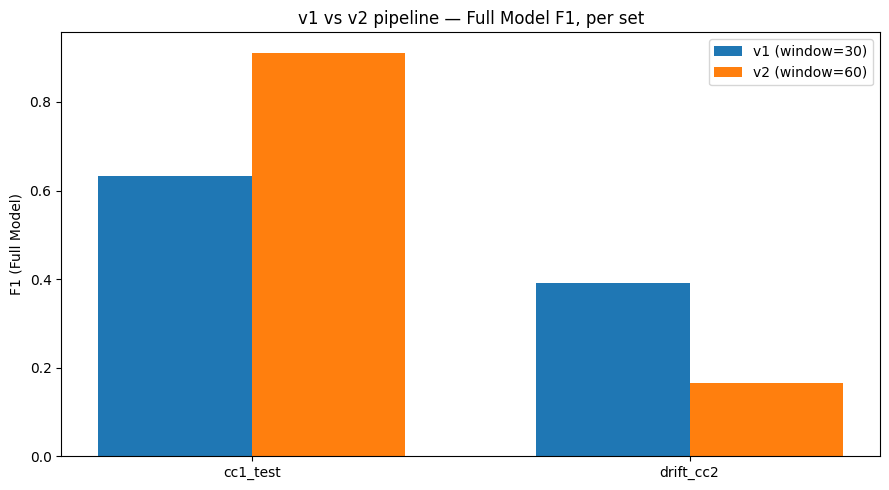

In [4]:
v1_ablation = v1_final['ablation_study']
print(f'{"set":12s} {"pipeline":20s} {"PR-AUC":>8s} {"F1":>7s} {"Precision":>10s} {"Recall":>8s}')
for name in ALL_SETS:
    v1m = v1_ablation['full_model'][name]
    v2m = ablation_v2['full_model'][name]
    print(f'{name:12s} {"v1 (window=30)":20s} {v1m["auc_pr"]:8.4f} {v1m["f1"]:7.3f} {v1m["precision"]:10.3f} {v1m["recall"]:8.3f}')
    print(f'{name:12s} {"v2 (window=60)":20s} {v2m["auc_pr"]:8.4f} {v2m["f1"]:7.3f} {v2m["precision"]:10.3f} {v2m["recall"]:8.3f}')
    print(f'  -> F1 change (v2 vs v1): {v2m["f1"]-v1m["f1"]:+.3f}\n')

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ALL_SETS)); width = 0.35
v1_f1 = [v1_ablation['full_model'][name]['f1'] for name in ALL_SETS]
v2_f1 = [ablation_v2['full_model'][name]['f1'] for name in ALL_SETS]
ax.bar(x - width/2, v1_f1, width, label='v1 (window=30)')
ax.bar(x + width/2, v2_f1, width, label='v2 (window=60)')
ax.set_xticks(x); ax.set_xticklabels(ALL_SETS)
ax.set_ylabel('F1 (Full Model)'); ax.set_title('v1 vs v2 pipeline — Full Model F1, per set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'v1_vs_v2_comparison.png'), dpi=120)
plt.show()

## Save

In [5]:
save_results = {
    'baseline_comparison': baseline_eval,
    'ablation_study': ablation_v2,
    'v1_vs_v2': {name: {'v1_full_model_f1': v1_ablation['full_model'][name]['f1'],
                         'v2_full_model_f1': ablation_v2['full_model'][name]['f1']}
                 for name in ALL_SETS},
}
out_path = os.path.join(MODEL_DIR, 'final_comparison_results.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(save_results, f)
print(f'Saved -> {out_path}')

Saved -> c:\Users\jthar\Documents\Claude\Projects\module3\module3\models_v2\final_comparison_results.pkl


## How to read this

**Section 3 is the decision table.** Window=60 (v2) wins decisively on
`cc1_test`; window=30 (v1) wins decisively on `drift_cc2`. There is no
single "better" pipeline in absolute terms — the choice depends on whether
in-distribution accuracy or drift robustness matters more for the deployment
this module targets. Both numbers are reported honestly, side by side, with
no attempt to declare one pipeline an unconditional winner.